<a href="https://colab.research.google.com/github/PranavSrikarthik12/NeuralNetworks_CourseWork/blob/main/ModelA%26B.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import time
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

from torch.utils.data import TensorDataset, DataLoader

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


In [ ]:
data = load_breast_cancer()

X = data.data
y = data.target

print("Features :", X.shape)
print("Labels   :", y.shape)

Features : (569, 30)
Labels   : (569,)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.float32).view(-1,1)
y_test = torch.tensor(y_test, dtype=torch.float32).view(-1,1)

In [ ]:
train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

In [ ]:
class BinaryClassifier(nn.Module):

    def __init__(self):
        super(BinaryClassifier, self).__init__()

        self.network = nn.Sequential(

            nn.Linear(30,64),
            nn.ReLU(),

            nn.Linear(64,32),
            nn.ReLU(),

            nn.Linear(32,1)

        )

    def forward(self,x):
        return self.network(x)

In [ ]:
model_mse = BinaryClassifier().to(device)

In [ ]:
criterion = nn.MSELoss()

optimizer = optim.Adam(
    model_mse.parameters(),
    lr=0.001
)

In [ ]:
num_epochs = 30

train_losses = []
train_accuracies = []

start_time = time.time()

for epoch in range(num_epochs):

    model_mse.train()

    running_loss = 0
    correct = 0
    total = 0

    for inputs, labels in train_loader:

        inputs = inputs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model_mse(inputs)

        # Convert logits to probabilities
        probabilities = torch.sigmoid(outputs)

        loss = criterion(probabilities, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        predicted = (probabilities >= 0.5).float()

        correct += (predicted == labels).sum().item()

        total += labels.size(0)

    epoch_loss = running_loss / len(train_loader)
    epoch_accuracy = correct / total

    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_accuracy)

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Loss: {epoch_loss:.4f} "
        f"Accuracy: {epoch_accuracy:.4f}"
    )

training_time = time.time() - start_time

Epoch [1/30] Loss: 0.2136 Accuracy: 0.8791
Epoch [2/30] Loss: 0.1401 Accuracy: 0.9582
Epoch [3/30] Loss: 0.0760 Accuracy: 0.9648
Epoch [4/30] Loss: 0.0402 Accuracy: 0.9692
Epoch [5/30] Loss: 0.0301 Accuracy: 0.9780
Epoch [6/30] Loss: 0.0217 Accuracy: 0.9846
Epoch [7/30] Loss: 0.0200 Accuracy: 0.9824
Epoch [8/30] Loss: 0.0174 Accuracy: 0.9868
Epoch [9/30] Loss: 0.0144 Accuracy: 0.9868
Epoch [10/30] Loss: 0.0129 Accuracy: 0.9890
Epoch [11/30] Loss: 0.0122 Accuracy: 0.9912
Epoch [12/30] Loss: 0.0127 Accuracy: 0.9912
Epoch [13/30] Loss: 0.0104 Accuracy: 0.9912
Epoch [14/30] Loss: 0.0099 Accuracy: 0.9912
Epoch [15/30] Loss: 0.0091 Accuracy: 0.9912
Epoch [16/30] Loss: 0.0090 Accuracy: 0.9912
Epoch [17/30] Loss: 0.0086 Accuracy: 0.9912
Epoch [18/30] Loss: 0.0077 Accuracy: 0.9912
Epoch [19/30] Loss: 0.0074 Accuracy: 0.9912
Epoch [20/30] Loss: 0.0071 Accuracy: 0.9912
Epoch [21/30] Loss: 0.0068 Accuracy: 0.9912
Epoch [22/30] Loss: 0.0065 Accuracy: 0.9934
Epoch [23/30] Loss: 0.0069 Accuracy: 0.99

In [ ]:
model_mse.eval()

correct = 0
total = 0

with torch.no_grad():

    for inputs, labels in test_loader:

        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs = model_mse(inputs)

        probabilities = torch.sigmoid(outputs)

        predicted = (probabilities >= 0.5).float()

        correct += (predicted == labels).sum().item()

        total += labels.size(0)

test_accuracy = correct / total

print("\nTest Accuracy :", round(test_accuracy*100,2),"%")
print("Training Time :", round(training_time,2),"seconds")


Test Accuracy : 95.61 %
Training Time : 0.94 seconds


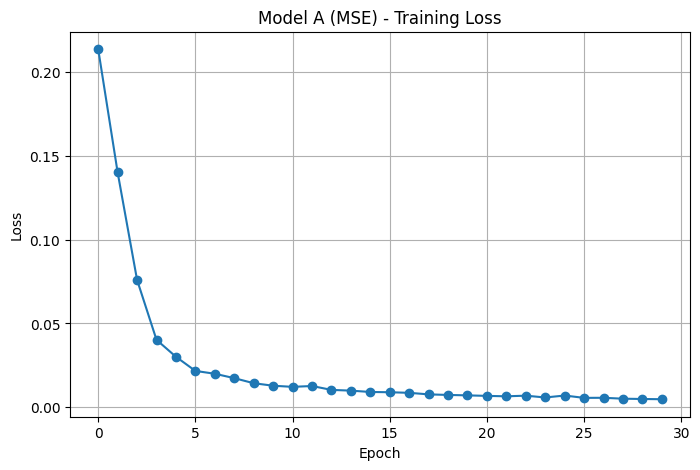

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(train_losses, marker='o')
plt.title("Model A (MSE) - Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

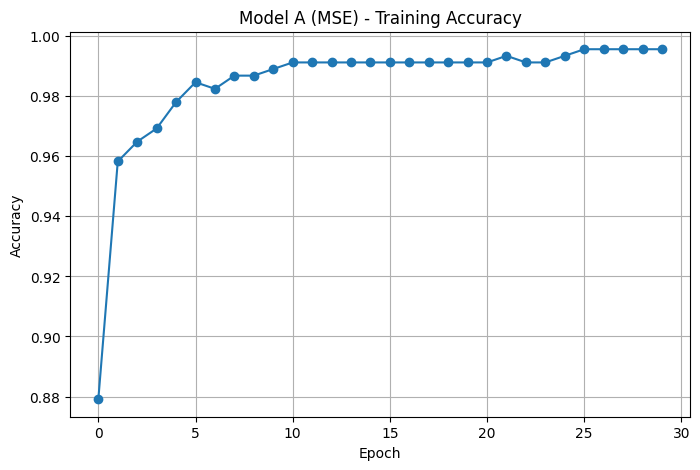

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(train_accuracies, marker='o')
plt.title("Model A (MSE) - Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()

**MODEL B**

In [ ]:
model_bce = BinaryClassifier().to(device)

In [ ]:
criterion = nn.BCEWithLogitsLoss()

optimizer = optim.Adam(
    model_bce.parameters(),
    lr=0.001
)

In [ ]:
num_epochs = 30

train_losses_bce = []
train_accuracies_bce = []

start_time = time.time()

for epoch in range(num_epochs):

    model_bce.train()

    running_loss = 0
    correct = 0
    total = 0

    for inputs, labels in train_loader:

        inputs = inputs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model_bce(inputs)

        # BCEWithLogitsLoss expects raw logits
        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        # Convert logits to probabilities only for prediction
        probabilities = torch.sigmoid(outputs)

        predicted = (probabilities >= 0.5).float()

        correct += (predicted == labels).sum().item()

        total += labels.size(0)

    epoch_loss = running_loss / len(train_loader)
    epoch_accuracy = correct / total

    train_losses_bce.append(epoch_loss)
    train_accuracies_bce.append(epoch_accuracy)

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Loss: {epoch_loss:.4f} "
        f"Accuracy: {epoch_accuracy:.4f}"
    )

training_time_bce = time.time() - start_time

Epoch [1/30] Loss: 0.6198 Accuracy: 0.7912
Epoch [2/30] Loss: 0.4456 Accuracy: 0.9451
Epoch [3/30] Loss: 0.2749 Accuracy: 0.9516
Epoch [4/30] Loss: 0.1726 Accuracy: 0.9648
Epoch [5/30] Loss: 0.1151 Accuracy: 0.9780
Epoch [6/30] Loss: 0.0892 Accuracy: 0.9824
Epoch [7/30] Loss: 0.0716 Accuracy: 0.9824
Epoch [8/30] Loss: 0.0620 Accuracy: 0.9890
Epoch [9/30] Loss: 0.0556 Accuracy: 0.9868
Epoch [10/30] Loss: 0.0592 Accuracy: 0.9868
Epoch [11/30] Loss: 0.0475 Accuracy: 0.9890
Epoch [12/30] Loss: 0.0438 Accuracy: 0.9890
Epoch [13/30] Loss: 0.0415 Accuracy: 0.9912
Epoch [14/30] Loss: 0.0400 Accuracy: 0.9912
Epoch [15/30] Loss: 0.0355 Accuracy: 0.9912
Epoch [16/30] Loss: 0.0328 Accuracy: 0.9912
Epoch [17/30] Loss: 0.0308 Accuracy: 0.9912
Epoch [18/30] Loss: 0.0414 Accuracy: 0.9912
Epoch [19/30] Loss: 0.0295 Accuracy: 0.9912
Epoch [20/30] Loss: 0.0264 Accuracy: 0.9934
Epoch [21/30] Loss: 0.0243 Accuracy: 0.9912
Epoch [22/30] Loss: 0.0231 Accuracy: 0.9912
Epoch [23/30] Loss: 0.0216 Accuracy: 0.99

In [ ]:
model_bce.eval()

correct = 0
total = 0

with torch.no_grad():

    for inputs, labels in test_loader:

        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs = model_bce(inputs)

        probabilities = torch.sigmoid(outputs)

        predicted = (probabilities >= 0.5).float()

        correct += (predicted == labels).sum().item()

        total += labels.size(0)

test_accuracy_bce = correct / total

print("\nTest Accuracy :", round(test_accuracy_bce * 100, 2), "%")
print("Training Time :", round(training_time_bce, 2), "seconds")


Test Accuracy : 95.61 %
Training Time : 0.76 seconds


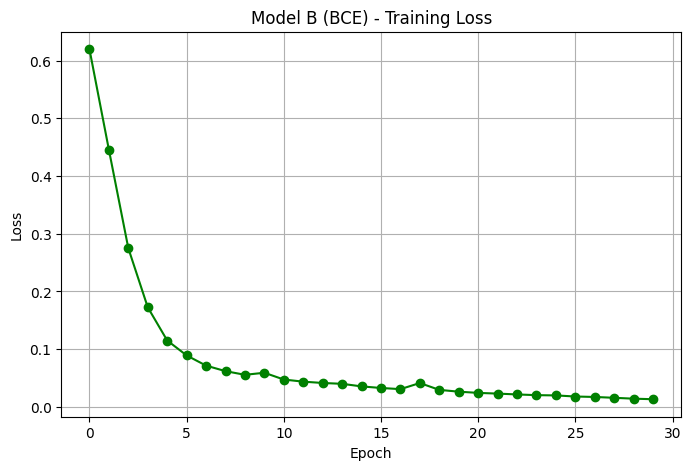

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(train_losses_bce, marker='o', color='green')
plt.title("Model B (BCE) - Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

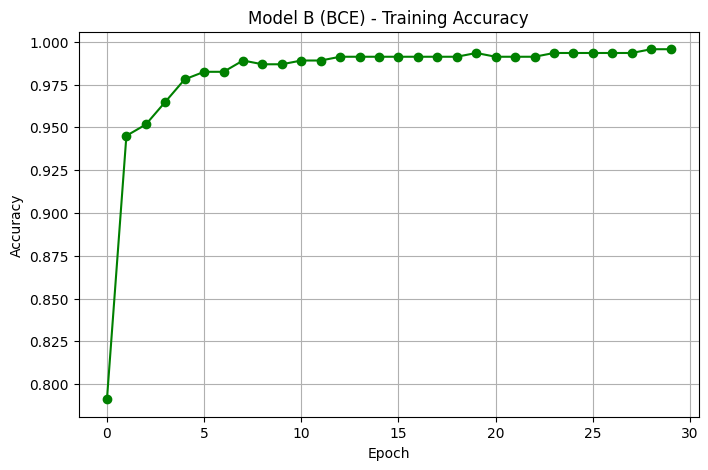

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(train_accuracies_bce, marker='o', color='green')
plt.title("Model B (BCE) - Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()

Compare Training Loss

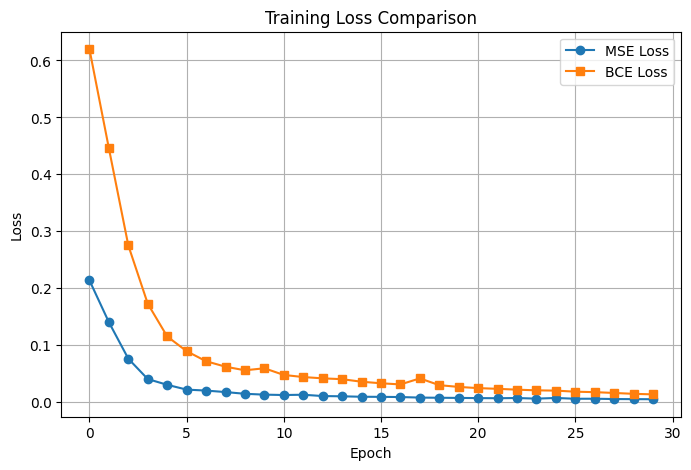

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(train_losses, label="MSE Loss", marker='o')
plt.plot(train_losses_bce, label="BCE Loss", marker='s')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.grid(True)
plt.show()

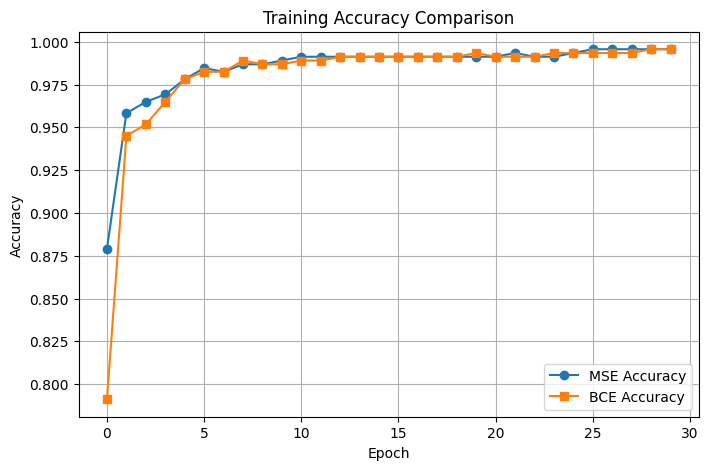

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(train_accuracies, label="MSE Accuracy", marker='o')
plt.plot(train_accuracies_bce, label="BCE Accuracy", marker='s')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training Accuracy Comparison")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
print("=" * 45)
print("Model Comparison")
print("=" * 45)

print(f"MSE Test Accuracy : {test_accuracy * 100:.2f}%")
print(f"BCE Test Accuracy : {test_accuracy_bce * 100:.2f}%")

print()

print(f"MSE Training Time : {training_time:.2f} sec")
print(f"BCE Training Time : {training_time_bce:.2f} sec")

Model Comparison
MSE Test Accuracy : 95.61%
BCE Test Accuracy : 95.61%

MSE Training Time : 0.94 sec
BCE Training Time : 0.76 sec
